<a href="https://colab.research.google.com/github/Akshatha-Gadasandula/DL_LAB/blob/main/DL_LAB_WEEK4_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#USING OPTIMIZATION ALGO
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import altair as alt



# expected values
y = np.array([[0, 1, 1, 0]]).T

# features
X = np.array([[0, 0, 1, 1],
              [0, 1, 0, 1]]).T


model = Sequential()
model.add(Dense(16, input_dim=2, activation='sigmoid'))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='mean_squared_error',
              optimizer='adam',
              metrics=['binary_accuracy', 'mean_squared_error'])

history = model.fit(X, y, epochs=1000, verbose=0)


errors = history.history['loss']

df2 = pd.DataFrame({"errors":errors, "time-step": np.arange(0, len(errors))})

alt.Chart(df2).mark_line().encode(x="time-step", y="errors").properties(title='Chart 3')


y_pred = model.predict(X).round()
num_correct_predictions = (y_pred == y).sum()
accuracy = (num_correct_predictions / y.shape[0]) * 100
print('Multi-layer perceptron accuracy: %.2f%%' % accuracy)




/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Multi-layer perceptron accuracy: 75.00%


In [ ]:
# Using SGD Optimizer
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import altair as alt
from tensorflow.keras.optimizers import SGD

# expected values
y = np.array([[0, 1, 1, 0]]).T

# features
X = np.array([[0, 0, 1, 1],
              [0, 1, 0, 1]]).T

model_sgd = Sequential()
model_sgd.add(Dense(16, input_dim=2, activation='sigmoid'))
model_sgd.add(Dense(1, activation='sigmoid'))

model_sgd.compile(loss='mean_squared_error',
                  optimizer=SGD(),
                  metrics=['binary_accuracy', 'mean_squared_error'])

history_sgd = model_sgd.fit(X, y, epochs=1000, verbose=0)

errors_sgd = history_sgd.history['loss']

df_sgd = pd.DataFrame({"errors": errors_sgd, "time-step": np.arange(0, len(errors_sgd))})

# Visualization with Altair for SGD optimizer
alt.Chart(df_sgd).mark_line().encode(x="time-step", y="errors").properties(title='SGD Optimizer - Loss Curve')

# Predictions and Accuracy
y_pred_sgd = model_sgd.predict(X).round()
num_correct_predictions_sgd = (y_pred_sgd == y).sum()
accuracy_sgd = (num_correct_predictions_sgd / y.shape[0]) * 100
print('SGD Optimizer accuracy: %.2f%%' % accuracy_sgd)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
SGD Optimizer accuracy: 50.00%


In [ ]:
# Using MGD (Momentum Gradient Descent) Optimizer
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import altair as alt
from tensorflow.keras.optimizers import SGD
# expected values
y = np.array([[0, 1, 1, 0]]).T

# features
X = np.array([[0, 0, 1, 1],
              [0, 1, 0, 1]]).T
model_mgd = Sequential()
model_mgd.add(Dense(16, input_dim=2, activation='sigmoid'))
model_mgd.add(Dense(1, activation='sigmoid'))

# Using Momentum in SGD
model_mgd.compile(loss='mean_squared_error',
                  optimizer=SGD(momentum=0.1),
                  metrics=['binary_accuracy', 'mean_squared_error'])
#momentum= 0.9 This parameter indicates how much of the previous update to consider when updating the current weight.
#momentum=0.9 would mean that 90% of the previous weight update is added to the current update, which can help the model converge more quickly.

history_mgd = model_mgd.fit(X, y, epochs=1000, verbose=0)

errors_mgd = history_mgd.history['loss']

df_mgd = pd.DataFrame({"errors": errors_mgd, "time-step": np.arange(0, len(errors_mgd))})

# Visualization with Altair for MGD optimizer
alt.Chart(df_mgd).mark_line().encode(x="time-step", y="errors").properties(title='MGD Optimizer - Loss Curve')

# Predictions and Accuracy
y_pred_mgd = model_mgd.predict(X).round()
num_correct_predictions_mgd = (y_pred_mgd == y).sum()
accuracy_mgd = (num_correct_predictions_mgd / y.shape[0]) * 100
print('MGD Optimizer accuracy: %.2f%%' % accuracy_mgd)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
MGD Optimizer accuracy: 50.00%


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
(50000, 32, 32, 3)


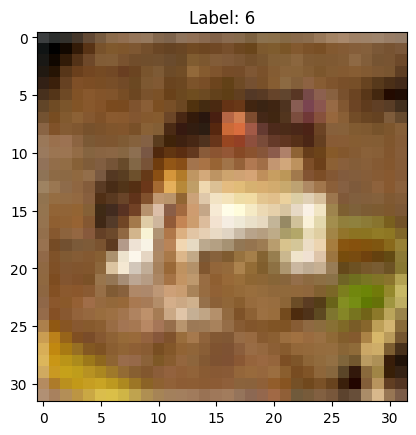

In [ ]:
from tensorflow.keras.datasets import cifar10
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Shape check: (50000, 32, 32, 3), labels 0-9
print(x_train.shape)  # (50000, 32, 32, 3)

# Visualize first image (e.g., frog if label=6)
plt.imshow(x_train[0])
plt.title(f'Label: {y_train[0][0]}')
plt.show()


Training MLP with SGD on CIFAR-10...
Epoch 1/20
50000/50000 ━━━━━━━━━━━━━━━━━━━━ 191s 4ms/step - accuracy: 0.2096 - loss: 2.1055 - val_accuracy: 0.3247 - val_loss: 1.8897
Epoch 2/20
50000/50000 ━━━━━━━━━━━━━━━━━━━━ 190s 4ms/step - accuracy: 0.2851 - loss: 1.9416 - val_accuracy: 0.3301 - val_loss: 1.8445
Epoch 3/20
50000/50000 ━━━━━━━━━━━━━━━━━━━━ 186s 4ms/step - accuracy: 0.2978 - loss: 1.9209 - val_accuracy: 0.3533 - val_loss: 1.7829
Epoch 4/20
50000/50000 ━━━━━━━━━━━━━━━━━━━━ 183s 4ms/step - accuracy: 0.3135 - loss: 1.8888 - val_accuracy: 0.3388 - val_loss: 1.8354
Epoch 5/20
50000/50000 ━━━━━━━━━━━━━━━━━━━━ 196s 4ms/step - accuracy: 0.3131 - loss: 1.8911 - val_accuracy: 0.3441 - val_loss: 1.8264
Epoch 6/20
50000/50000 ━━━━━━━━━━━━━━━━━━━━ 214s 4ms/step - accuracy: 0.3170 - loss: 1.8790 - val_accuracy: 0.3598 - val_loss: 1.7914
Epoch 7/20
50000/50000 ━━━━━━━━━━━━━━━━━━━━ 208s 4ms/step - accuracy: 0.3206 - loss: 1.8824 - val_accuracy: 0.3701 - val_loss: 1.7810
Epoch 8/20
50000/50000 ━━

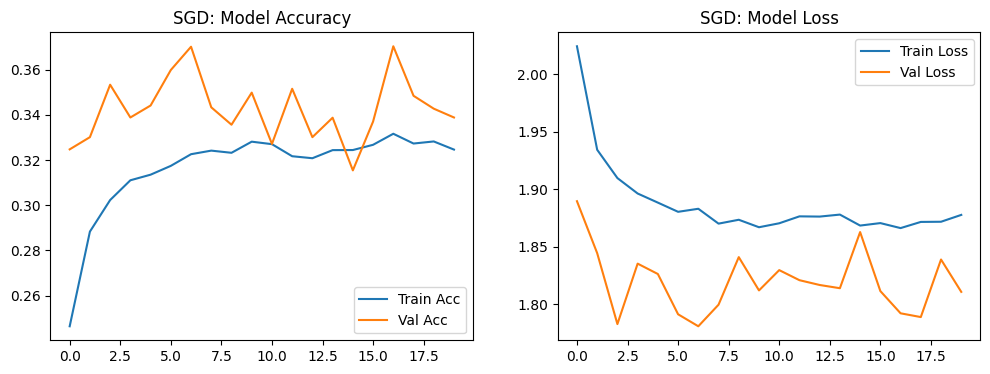

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt

# Load and preprocess CIFAR-10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
x_train = x_train.reshape(x_train.shape[0], -1)  # Flatten: 50k x 3072
x_test = x_test.reshape(x_test.shape[0], -1)
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# MLP Architecture
model = tf.keras.Sequential([
    tf.keras.layers.Dense(512, activation='relu', input_shape=(3072,)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

# SGD Optimizer (batch_size=1 for true stochastic)
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.0),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("Training MLP with SGD on CIFAR-10...")
history = model.fit(x_train, y_train,
                   batch_size=1,  # True SGD
                   epochs=20,
                   validation_data=(x_test, y_test),
                   verbose=1)

# Final evaluation
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\nSGD Final Test Accuracy: {test_acc:.4f}")

# Plot training curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('SGD: Model Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('SGD: Model Loss')
plt.legend()
plt.show()


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training using Batch Gradient Descent (BGD)...
Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - accuracy: 0.1030 - loss: 2.3892 - val_accuracy: 0.1168 - val_loss: 2.3117
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step - accuracy: 0.1037 - loss: 2.3647 - val_accuracy: 0.1231 - val_loss: 2.3004
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.1072 - loss: 2.3496 - val_accuracy: 0.1319 - val_loss: 2.2928
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step - accuracy: 0.1089 - loss: 2.3421 - val_accuracy: 0.1382 - val_loss: 2.2871
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.1114 - loss: 2.3315 - val_accuracy: 0.1432 - val_loss: 2.2823
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step - accuracy: 0.1143 - loss: 2.3262 - val_accuracy: 0.1484 - val_loss: 2.2782
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.1172 - loss: 2.3194 - val_accuracy: 0.1513 - val_loss: 2.2744
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step - accuracy: 0.1209 - loss: 2.3145 - v

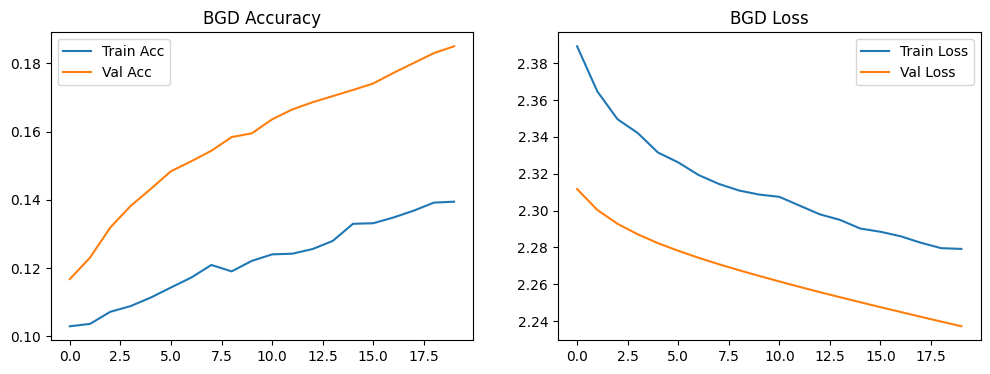

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# =========================
# Load and preprocess data
# =========================
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Flatten images (32x32x3 → 3072)
x_train = x_train.reshape(x_train.shape[0], -1)
x_test = x_test.reshape(x_test.shape[0], -1)

# One-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# =========================
# MLP Model
# =========================
model = tf.keras.Sequential([
    tf.keras.layers.Dense(512, activation='relu', input_shape=(3072,)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

# =========================
# BGD Optimizer
# =========================
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("Training using Batch Gradient Descent (BGD)...")

# Full dataset as one batch
history = model.fit(x_train, y_train,
                    batch_size=len(x_train),
                    epochs=20,
                    validation_data=(x_test, y_test),
                    verbose=1)

# =========================
# Evaluation
# =========================
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\nBGD Test Accuracy: {test_acc:.4f}")

# =========================
# Plot graphs
# =========================
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("BGD Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("BGD Loss")
plt.legend()

plt.show()

Training using Mini-Batch Gradient Descent (MGD)...
Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.2146 - loss: 2.1295 - val_accuracy: 0.3215 - val_loss: 1.8702
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.3350 - loss: 1.8537 - val_accuracy: 0.3472 - val_loss: 1.8283
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.3702 - loss: 1.7614 - val_accuracy: 0.3793 - val_loss: 1.7118
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.3955 - loss: 1.7043 - val_accuracy: 0.3563 - val_loss: 1.8452
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.4120 - loss: 1.6571 - val_accuracy: 0.4215 - val_loss: 1.6095
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.4212 - loss: 1.6184 - val_accuracy: 0.4533 - val_loss: 1.5502
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.4385 - loss: 1.5948 - val_accuracy: 0.4476 - val_loss: 1.5538
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━

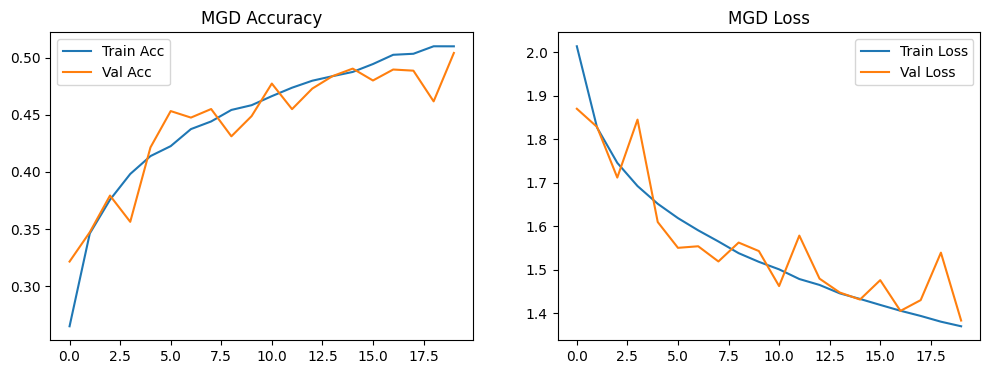

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# =========================
# Load and preprocess data
# =========================
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Flatten images
x_train = x_train.reshape(x_train.shape[0], -1)
x_test = x_test.reshape(x_test.shape[0], -1)

# One-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# =========================
# MLP Model
# =========================
model = tf.keras.Sequential([
    tf.keras.layers.Dense(512, activation='relu', input_shape=(3072,)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

# =========================
# MGD Optimizer (same SGD, different batch size)
# =========================
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("Training using Mini-Batch Gradient Descent (MGD)...")

# Mini-batch size (commonly 32 or 64)
history = model.fit(x_train, y_train,
                    batch_size=64,
                    epochs=20,
                    validation_data=(x_test, y_test),
                    verbose=1)

# =========================
# Evaluation
# =========================
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\nMGD Test Accuracy: {test_acc:.4f}")

# =========================
# Plot graphs
# =========================
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("MGD Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("MGD Loss")
plt.legend()

plt.show()

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(512, activation='relu', input_shape=(3072,)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train, batch_size=64, epochs=20,
                    validation_data=(x_test, y_test))

test_loss, test_acc = model.evaluate(x_test, y_test)
print("Nesterov Accuracy:", test_acc)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.2626 - loss: 2.0087 - val_accuracy: 0.3723 - val_loss: 1.7360
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.3683 - loss: 1.7646 - val_accuracy: 0.4007 - val_loss: 1.6779
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.3891 - loss: 1.6996 - val_accuracy: 0.4246 - val_loss: 1.6005
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.4048 - loss: 1.6504 - val_accuracy: 0.4514 - val_loss: 1.5437
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.4190 - loss: 1.6080 - val_accuracy: 0.4507 - val_loss: 1.5502
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.4331 - loss: 1.5828 - val_accuracy: 0.4674 - val_loss: 1.4919
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.4373 - loss: 1.5533 - val_accuracy: 0.4628 - val_loss: 1.4985
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.4530 - loss: 1.5214 - 

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(512, activation='relu', input_shape=(3072,)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer=tf.keras.optimizers.Adagrad(learning_rate=0.01),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train, batch_size=64, epochs=20,
                    validation_data=(x_test, y_test))

test_loss, test_acc = model.evaluate(x_test, y_test)
print("Adagrad Accuracy:", test_acc)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.2362 - loss: 2.0704 - val_accuracy: 0.3336 - val_loss: 1.8032
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.3598 - loss: 1.7865 - val_accuracy: 0.3645 - val_loss: 1.7791
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 16ms/step - accuracy: 0.3913 - loss: 1.7078 - val_accuracy: 0.4111 - val_loss: 1.6511
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.4126 - loss: 1.6496 - val_accuracy: 0.4247 - val_loss: 1.6213
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.4314 - loss: 1.5963 - val_accuracy: 0.4352 - val_loss: 1.5680
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.4403 - loss: 1.5703 - val_accuracy: 0.4413 - val_loss: 1.5588
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.4577 - loss: 1.5352 - val_accuracy: 0.4416 - val_loss: 1.5571
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.4630 - loss: 1.5048 - 

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(512, activation='relu', input_shape=(3072,)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train, batch_size=64, epochs=20,
                    validation_data=(x_test, y_test))

test_loss, test_acc = model.evaluate(x_test, y_test)
print("RMSProp Accuracy:", test_acc)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.2123 - loss: 2.2076 - val_accuracy: 0.3130 - val_loss: 1.9097
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.3239 - loss: 1.8584 - val_accuracy: 0.3750 - val_loss: 1.7795
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.3526 - loss: 1.7852 - val_accuracy: 0.3545 - val_loss: 1.7647
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.3755 - loss: 1.7422 - val_accuracy: 0.3399 - val_loss: 1.7834
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.3829 - loss: 1.7117 - val_accuracy: 0.3861 - val_loss: 1.7395
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.3955 - loss: 1.6872 - val_accuracy: 0.3894 - val_loss: 1.6531
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.4009 - loss: 1.6672 - val_accuracy: 0.4192 - val_loss: 1.6248
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.4066 - loss: 1.6529 - 

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(512, activation='relu', input_shape=(3072,)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer=tf.keras.optimizers.Adadelta(),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train, batch_size=64, epochs=20,
                    validation_data=(x_test, y_test))

test_loss, test_acc = model.evaluate(x_test, y_test)
print("Adadelta Accuracy:", test_acc)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.1141 - loss: 2.3478 - val_accuracy: 0.1755 - val_loss: 2.2176
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.1655 - loss: 2.2410 - val_accuracy: 0.2270 - val_loss: 2.1573
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.1994 - loss: 2.1881 - val_accuracy: 0.2606 - val_loss: 2.1092
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.2181 - loss: 2.1480 - val_accuracy: 0.2735 - val_loss: 2.0718
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - accuracy: 0.2286 - loss: 2.1193 - val_accuracy: 0.2825 - val_loss: 2.0428
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 20ms/step - accuracy: 0.2418 - loss: 2.0880 - val_accuracy: 0.2932 - val_loss: 2.0169
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.2497 - loss: 2.0730 - val_accuracy: 0.2997 - val_loss: 1.9974
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.2581 - loss: 2.0534 - 

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(512, activation='relu', input_shape=(3072,)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train, batch_size=64, epochs=20,
                    validation_data=(x_test, y_test))

test_loss, test_acc = model.evaluate(x_test, y_test)
print("Adam Accuracy:", test_acc)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.2217 - loss: 2.1124 - val_accuracy: 0.3564 - val_loss: 1.7946
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.3311 - loss: 1.8454 - val_accuracy: 0.3685 - val_loss: 1.7605
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.3457 - loss: 1.7891 - val_accuracy: 0.3805 - val_loss: 1.7369
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.3682 - loss: 1.7533 - val_accuracy: 0.4132 - val_loss: 1.6448
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.3712 - loss: 1.7258 - val_accuracy: 0.4200 - val_loss: 1.6165
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 20ms/step - accuracy: 0.3855 - loss: 1.6949 - val_accuracy: 0.4125 - val_loss: 1.6243
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 19ms/step - accuracy: 0.3980 - loss: 1.6677 - val_accuracy: 0.4131 - val_loss: 1.6151
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.4028 - loss: 1.6480 - 

# WEEK 5

In [12]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

# Load CIFAR-10
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten for MLP
x_train = x_train.reshape(-1, 32*32*3)
x_test = x_test.reshape(-1, 32*32*3)

# Baseline model
model = keras.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=20,
                    validation_split=0.2, batch_size=128)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 44ms/step - accuracy: 0.3058 - loss: 1.9411 - val_accuracy: 0.3606 - val_loss: 1.7866
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.3936 - loss: 1.7072 - val_accuracy: 0.4108 - val_loss: 1.6671
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.4177 - loss: 1.6315 - val_accuracy: 0.4150 - val_loss: 1.6590
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 39ms/step - accuracy: 0.4427 - loss: 1.5692 - val_accuracy: 0.4433 - val_loss: 1.5954
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step - accuracy: 0.4529 - loss: 1.5283 - val_accuracy: 0.4526 - val_loss: 1.5588
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - accuracy: 0.4725 - loss: 1.4809 - val_accuracy: 0.4399 - val_loss: 1.5809
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 47ms/step - accuracy: 0.4850 - loss: 1.4446 - val_accuracy: 0.4546 - val_loss: 1.5316
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━

In [13]:
#L2 REGULARIZATION
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
model_l2 = keras.Sequential([
    layers.Dense(512, activation='relu',
                 kernel_regularizer=keras.regularizers.l2(0.001),
                 input_shape=(3072,)),
    layers.Dense(256, activation='relu',
                 kernel_regularizer=keras.regularizers.l2(0.001)),
    layers.Dense(10, activation='softmax')
])

model_l2.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

history_l2 = model_l2.fit(x_train, y_train,
                          epochs=20,
                          validation_split=0.2,
                          batch_size=128)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 47ms/step - accuracy: 0.3095 - loss: 2.4684 - val_accuracy: 0.3606 - val_loss: 2.0833
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 58ms/step - accuracy: 0.3798 - loss: 1.9454 - val_accuracy: 0.3847 - val_loss: 1.8886
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 46ms/step - accuracy: 0.4092 - loss: 1.8002 - val_accuracy: 0.3865 - val_loss: 1.9242
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - accuracy: 0.4312 - loss: 1.7275 - val_accuracy: 0.4339 - val_loss: 1.7232
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 46ms/step - accuracy: 0.4408 - loss: 1.6844 - val_accuracy: 0.4405 - val_loss: 1.6790
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 43ms/step - accuracy: 0.4499 - loss: 1.6482 - val_accuracy: 0.4446 - val_loss: 1.6839
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 43ms/step - accuracy: 0.4593 - loss: 1.6234 - val_accuracy: 0.4556 - val_loss: 1.6481
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - accuracy: 0.4624 - loss: 1.6087 - 

In [14]:
#DATASET AUGMENTATION
datagen = keras.preprocessing.image.ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

x_train_img = x_train.reshape(-1,32,32,3)

model_aug = keras.Sequential([
    layers.Flatten(input_shape=(32,32,3)),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_aug.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

history_aug = model_aug.fit(
    datagen.flow(x_train_img, y_train, batch_size=128),
    epochs=20,
    validation_data=(x_test.reshape(-1,32,32,3), y_test)
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 45s 113ms/step - accuracy: 0.2989 - loss: 1.9652 - val_accuracy: 0.3575 - val_loss: 1.7762
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 42s 106ms/step - accuracy: 0.3624 - loss: 1.7732 - val_accuracy: 0.4087 - val_loss: 1.6540
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 42s 107ms/step - accuracy: 0.3868 - loss: 1.7045 - val_accuracy: 0.4339 - val_loss: 1.5784
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 43s 109ms/step - accuracy: 0.4124 - loss: 1.6447 - val_accuracy: 0.4454 - val_loss: 1.5591
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 80s 105ms/step - accuracy: 0.4207 - loss: 1.6180 - val_accuracy: 0.4607 - val_loss: 1.5260
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 41s 106ms/step - accuracy: 0.4271 - loss: 1.5967 - val_accuracy: 0.4372 - val_loss: 1.5401
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 47s 119ms/step - accuracy: 0.4375 - loss: 1.5753 - val_accuracy: 0.4692 - val_loss: 1.4973
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 43s 109ms/step - accuracy: 0.4448 - loss: 1

In [25]:
#PARAMETER SHARING AND TYPING

shared_dense_layer = layers.Dense(256, activation='relu')

model_share = keras.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    shared_dense_layer, # First usage of the shared layer instance
    layers.Dense(256, activation='relu'), # A new layer instance with the same configuration
    layers.Dense(10, activation='softmax')
])

model_share.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])

history_share = model_share.fit(x_train, y_train,
                                epochs=20,
                                validation_split=0.2,
                                batch_size=128)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 44ms/step - accuracy: 0.3071 - loss: 1.9036 - val_accuracy: 0.3584 - val_loss: 1.7655
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - accuracy: 0.3889 - loss: 1.6987 - val_accuracy: 0.3954 - val_loss: 1.6820
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 43ms/step - accuracy: 0.4230 - loss: 1.6115 - val_accuracy: 0.3943 - val_loss: 1.6923
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - accuracy: 0.4475 - loss: 1.5470 - val_accuracy: 0.4403 - val_loss: 1.5787
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 43ms/step - accuracy: 0.4633 - loss: 1.4965 - val_accuracy: 0.4385 - val_loss: 1.5935
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - accuracy: 0.4751 - loss: 1.4622 - val_accuracy: 0.4342 - val_loss: 1.5778
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - accuracy: 0.4915 - loss: 1.4285 - val_accuracy: 0.4760 - val_loss: 1.4799
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - accuracy: 0.4999 - loss: 1.3929 - 

In [26]:
# Adding Noise to Inputs
model_noise = keras.Sequential([
    layers.GaussianNoise(0.1, input_shape=(3072,)),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_noise.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])

history_noise = model_noise.fit(x_train, y_train,
                                epochs=20,
                                validation_split=0.2,
                                batch_size=128)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/regularization/gaussian_noise.py:29: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 48ms/step - accuracy: 0.3088 - loss: 1.9308 - val_accuracy: 0.3727 - val_loss: 1.7644
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 47ms/step - accuracy: 0.3857 - loss: 1.7059 - val_accuracy: 0.3875 - val_loss: 1.7090
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 53ms/step - accuracy: 0.4204 - loss: 1.6269 - val_accuracy: 0.4233 - val_loss: 1.6291
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.4415 - loss: 1.5675 - val_accuracy: 0.4334 - val_loss: 1.5968
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 46ms/step - accuracy: 0.4570 - loss: 1.5247 - val_accuracy: 0.4449 - val_loss: 1.5736
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 46ms/step - accuracy: 0.4672 - loss: 1.4911 - val_accuracy: 0.4584 - val_loss: 1.5328
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.4746 - loss: 1.4628 - val_accuracy: 0.4611 - val_loss: 1.5165
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - accuracy: 0.4881 - loss: 1.4312 - 

In [27]:
#Early Stopping
callback = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

model_es = keras.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_es.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

history_es = model_es.fit(x_train, y_train,
                          epochs=50,
                          validation_split=0.2,
                          batch_size=128,
                          callbacks=[callback])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 43ms/step - accuracy: 0.3059 - loss: 1.9437 - val_accuracy: 0.3525 - val_loss: 1.8211
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step - accuracy: 0.3856 - loss: 1.7135 - val_accuracy: 0.3716 - val_loss: 1.7428
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - accuracy: 0.4198 - loss: 1.6262 - val_accuracy: 0.4269 - val_loss: 1.6151
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.4428 - loss: 1.5567 - val_accuracy: 0.4449 - val_loss: 1.5722
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.4604 - loss: 1.5148 - val_accuracy: 0.4548 - val_loss: 1.5431
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - accuracy: 0.4701 - loss: 1.4809 - val_accuracy: 0.4562 - val_loss: 1.5286
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.4828 - loss: 1.4494 - val_accuracy: 0.4544 - val_loss: 1.5378
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0.4963 - loss: 1.4171 - 

In [30]:
# DROPOUT
model_do = keras.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model_do.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

history_do = model_do.fit(x_train, y_train,
                          epochs=20,
                          validation_split=0.2,
                          batch_size=128)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - accuracy: 0.1952 - loss: 2.1561 - val_accuracy: 0.2707 - val_loss: 1.9924
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - accuracy: 0.2239 - loss: 2.0585 - val_accuracy: 0.2642 - val_loss: 2.0018
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 43ms/step - accuracy: 0.2331 - loss: 2.0222 - val_accuracy: 0.2938 - val_loss: 1.9778
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - accuracy: 0.2450 - loss: 2.0016 - val_accuracy: 0.2958 - val_loss: 1.9666
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 41ms/step - accuracy: 0.2515 - loss: 1.9813 - val_accuracy: 0.3091 - val_loss: 1.9603
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - accuracy: 0.2575 - loss: 1.9722 - val_accuracy: 0.3066 - val_loss: 1.9567
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - accuracy: 0.2626 - loss: 1.9629 - val_accuracy: 0.2884 - val_loss: 1.9572
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.2668 - loss: 1.9534 - 